           mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Oil    1.149979  7.803353 -47.52       -2.9050         1.010        4.9800   
Banks  1.244017  6.816028 -36.47       -1.8900         1.315        4.3800   
Txtls  0.978596  8.189742 -36.02       -3.1825         0.955        4.9725   
Toys   0.917862  9.761930 -43.34       -4.2625         0.960        5.5000   
Rtail  1.112196  6.836516 -31.29       -2.3025         1.090        4.4950   

          max   kurtosis  skewness  
Oil     68.84   7.629970  0.640366  
Banks   56.87   6.816107  0.213174  
Txtls   85.94  11.474771  1.218661  
Toys   104.10  15.251647  1.651421  
Rtail   72.09  11.736666  0.951643  


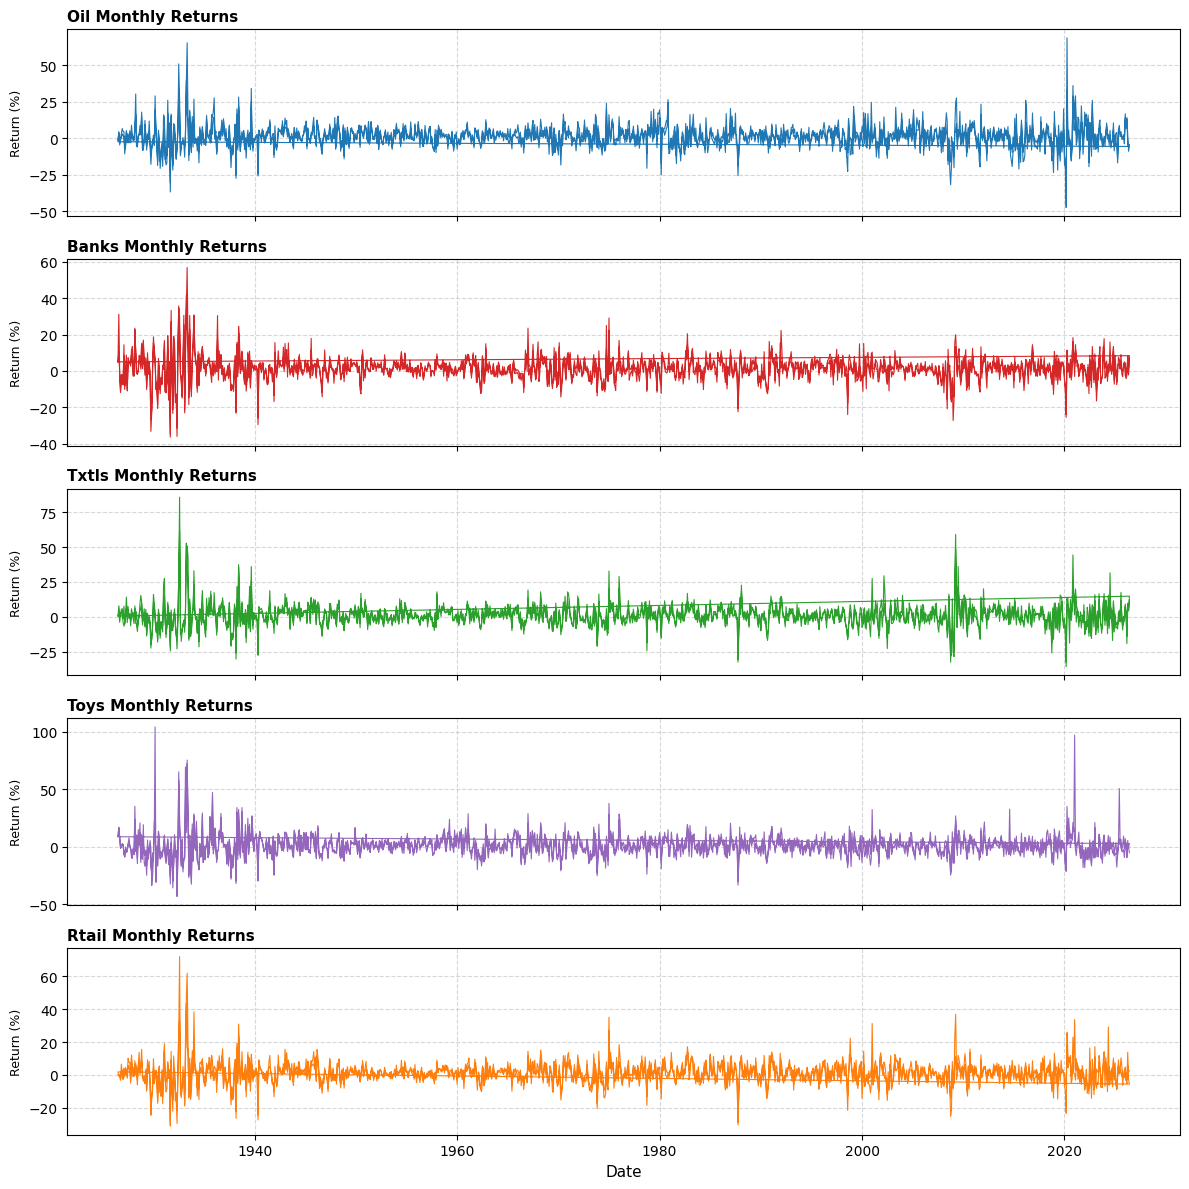

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV
returns = pd.read_csv('49_Industry_Portfolios.csv', skiprows=11, engine='python', on_bad_lines='skip')
FF5=pd.read_csv('F-F_Research_Data_5_Factors_2x3.csv', skiprows=4, engine='python', on_bad_lines='skip')
momentum=pd.read_csv('F-F_Momentum_Factor.csv', skiprows=13, engine='python', on_bad_lines='skip')

# Rename the first column to 'Date'
returns = returns.rename(columns={returns.columns[0]: 'Date'})
FF5 = FF5.rename(columns={FF5.columns[0]: 'Date'})
momentum = momentum.rename(columns={momentum.columns[0]: 'Date'})

#Cleaning up the column strings to remove white space
returns.columns = returns.columns.str.strip()
FF5.columns = FF5.columns.str.strip()
momentum.columns = momentum.columns.str.strip()

# Choosing which industries to use
keep_cols = ['Date', 'Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

# Only keep the chosen industry returns
returns = returns[keep_cols]

# Removing the unused rows
returns = returns.iloc[:2402].reset_index(drop=True)
FF5 = FF5.iloc[:756].reset_index(drop=True)
momentum = momentum.iloc[:1195].reset_index(drop=True)

# Change data type to numeric
returns = returns.apply(pd.to_numeric, errors='coerce')
FF5 = FF5.apply(pd.to_numeric, errors='coerce')
momentum = momentum.apply(pd.to_numeric, errors='coerce')


#
desc_stats = pd.DataFrame(
    {
        'mean': returns.drop(columns=['Date']).mean(),
        'std': returns.drop(columns=['Date']).std(),
        'min': returns.drop(columns=['Date']).min(),
        '25% Quartile': returns.drop(columns=['Date']).quantile(0.25),
        '50% (Median)': returns.drop(columns=['Date']).median(),
        '75% Quartile': returns.drop(columns=['Date']).quantile(0.75),
        'max': returns.drop(columns=['Date']).max(),
        'kurtosis': returns.drop(columns=['Date']).kurtosis(),
        'skewness': returns.drop(columns=['Date']).skew()
    }
)

print(desc_stats)

# Plot raw returns
# 1. Clean and convert Date safely to datetime
returns = returns.dropna(subset=['Date']).copy()
returns['Date'] = returns['Date'].replace([np.inf, -np.inf], np.nan)

# Convert float/int dates (e.g., 192607.0) to datetime strings YYYYMM
returns['Date'] = pd.to_datetime(
    returns['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)

# Remove any bad dates that failed conversion
returns = returns.dropna(subset=['Date'])

industry_cols = ['Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
# Create a 5x1 grid of plots sharing the same x-axis
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 12), sharex=True)

for ax, col,color in zip(axes, industry_cols,colors):
    ax.plot(returns['Date'], returns[col], linewidth=0.8, color=color)
    ax.set_title(f'{col} Monthly Returns', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()